In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (10,6)

In [4]:

data2023 = pd.read_csv('2023data.csv')

print("Dataset Shape:", data2023.shape)
print(data2023.head())


Dataset Shape: (77878, 14)
    addref      city assembly       body    make    model    year  engine  \
0  7943732  Peshawar      NaN      Sedan  Toyota  Corolla  2013.0  1300.0   
1  7730314    Lahore      NaN      Sedan   Honda     City  2000.0  1300.0   
2  7943737    Lahore      NaN      Sedan  Toyota    Yaris  2021.0  1300.0   
3  7943733    Lahore      NaN  Hatchback  Suzuki    Swift  2017.0  1300.0   
4  7923484    Lahore      NaN      Sedan   Honda    Civic  2017.0  1800.0   

  transmission    fuel            color registered  mileage      price  
0       Manual  Petrol  Silver Metallic     Lahore   145000  2870000.0  
1       Manual  Petrol             Blue     Lahore   230000   995000.0  
2       Manual  Petrol      Super White     Punjab    60500  3585000.0  
3       Manual  Petrol             Grey  Islamabad    87000  2250000.0  
4    Automatic  Petrol             Grey     Lahore    86000  4850000.0  


In [5]:
data2023

,addref,city,assembly,body,make,model,year,engine,transmission,fuel,color,registered,mileage,price
0,7943732,Peshawar,NaN,Sedan,Toyota,Corolla,2013.0,1300.0,Manual,Petrol,Silver Metallic,Lahore,145000,2870000.0
1,7730314,Lahore,NaN,Sedan,Honda,City,2000.0,1300.0,Manual,Petrol,Blue,Lahore,230000,995000.0
2,7943737,Lahore,NaN,Sedan,Toyota,Yaris,2021.0,1300.0,Manual,Petrol,Super White,Punjab,60500,3585000.0
3,7943733,Lahore,NaN,Hatchback,Suzuki,Swift,2017.0,1300.0,Manual,Petrol,Grey,Islamabad,87000,2250000.0
4,7923484,Lahore,NaN,Sedan,Honda,Civic,2017.0,1800.0,Automatic,Petrol,Grey,Lahore,86000,4850000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77873,7775164,Daska,NaN,Sedan,Honda,Civic,2019.0,1800.0,Automatic,Petrol,Taffeta White,Islamabad,58000,5590000.0
77874,7772775,Abbottabad,Imported,Hatchback,Suzuki,Alto,2015.0,660.0,Automatic,Petrol,Brown,Islamabad,65000,2420000.0
77875,7773716,Faisalabad,Imported,Crossover,MG,HS,2021.0,1490.0,Automatic,Petrol,Arctic White,Un-Registered,5000,7500000.0
77876,7322377,Quetta,NaN,Sedan,Suzuki,Baleno,2005.0,1300.0,Manual,Petrol,Silver,Lahore,19000,1250000.0


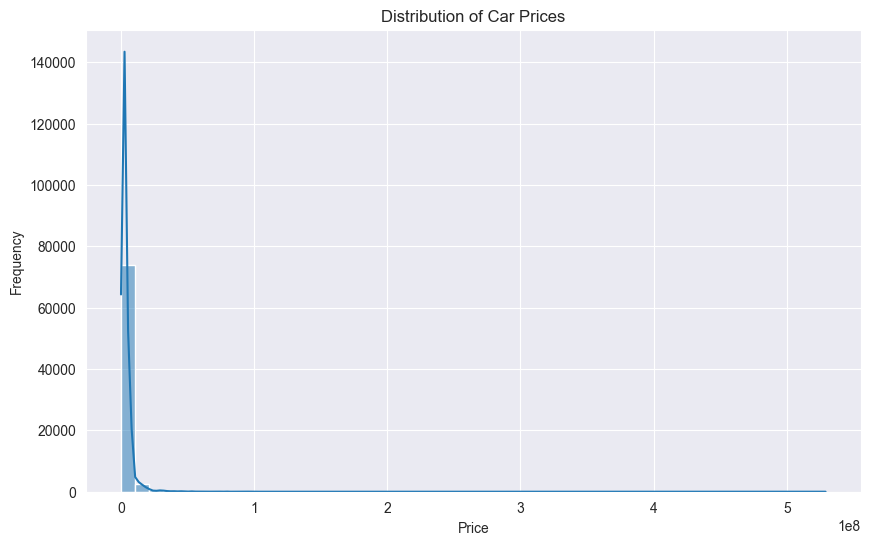

In [6]:
plt.figure()
sns.histplot(data2023['price'], bins=50, kde=True)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

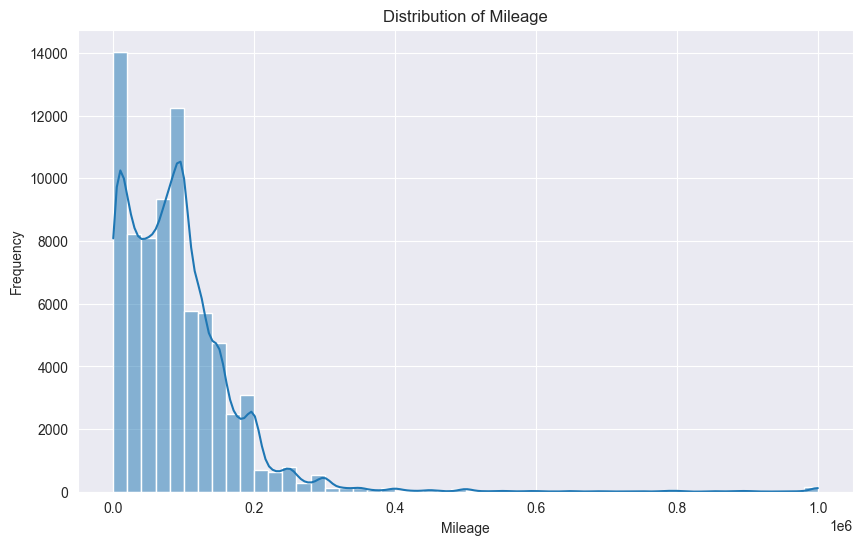

In [7]:

plt.figure()
sns.histplot(data2023['mileage'], bins=50, kde=True)
plt.title("Distribution of Mileage")
plt.xlabel("Mileage")
plt.ylabel("Frequency")
plt.show()

In [9]:

data2023.drop(
    ['addref','color','city','registered','fuel','make','body'],
    axis=1,
    errors='ignore',
    inplace=True
)
data2023

,assembly,model,year,engine,transmission,mileage,price
0,NaN,Corolla,2013.0,1300.0,Manual,145000,2870000.0
1,NaN,City,2000.0,1300.0,Manual,230000,995000.0
2,NaN,Yaris,2021.0,1300.0,Manual,60500,3585000.0
3,NaN,Swift,2017.0,1300.0,Manual,87000,2250000.0
4,NaN,Civic,2017.0,1800.0,Automatic,86000,4850000.0
...,...,...,...,...,...,...,...
77873,NaN,Civic,2019.0,1800.0,Automatic,58000,5590000.0
77874,Imported,Alto,2015.0,660.0,Automatic,65000,2420000.0
77875,Imported,HS,2021.0,1490.0,Automatic,5000,7500000.0
77876,NaN,Baleno,2005.0,1300.0,Manual,19000,1250000.0


In [10]:
data2023['transmission'] = data2023['transmission'].map({
    'Automatic': 1,
    'Manual': 0
})
data2023

,assembly,model,year,engine,transmission,mileage,price
0,NaN,Corolla,2013.0,1300.0,0,145000,2870000.0
1,NaN,City,2000.0,1300.0,0,230000,995000.0
2,NaN,Yaris,2021.0,1300.0,0,60500,3585000.0
3,NaN,Swift,2017.0,1300.0,0,87000,2250000.0
4,NaN,Civic,2017.0,1800.0,1,86000,4850000.0
...,...,...,...,...,...,...,...
77873,NaN,Civic,2019.0,1800.0,1,58000,5590000.0
77874,Imported,Alto,2015.0,660.0,1,65000,2420000.0
77875,Imported,HS,2021.0,1490.0,1,5000,7500000.0
77876,NaN,Baleno,2005.0,1300.0,0,19000,1250000.0


In [11]:
data2023['assembly'] = data2023['assembly'].fillna("local")
data2023

,assembly,model,year,engine,transmission,mileage,price
0,local,Corolla,2013.0,1300.0,0,145000,2870000.0
1,local,City,2000.0,1300.0,0,230000,995000.0
2,local,Yaris,2021.0,1300.0,0,60500,3585000.0
3,local,Swift,2017.0,1300.0,0,87000,2250000.0
4,local,Civic,2017.0,1800.0,1,86000,4850000.0
...,...,...,...,...,...,...,...
77873,local,Civic,2019.0,1800.0,1,58000,5590000.0
77874,Imported,Alto,2015.0,660.0,1,65000,2420000.0
77875,Imported,HS,2021.0,1490.0,1,5000,7500000.0
77876,local,Baleno,2005.0,1300.0,0,19000,1250000.0


In [12]:
data2023['assembly'] = data2023['assembly'].map({
    'Imported': 1,
    'local': 0
})
data2023

,assembly,model,year,engine,transmission,mileage,price
0,0,Corolla,2013.0,1300.0,0,145000,2870000.0
1,0,City,2000.0,1300.0,0,230000,995000.0
2,0,Yaris,2021.0,1300.0,0,60500,3585000.0
3,0,Swift,2017.0,1300.0,0,87000,2250000.0
4,0,Civic,2017.0,1800.0,1,86000,4850000.0
...,...,...,...,...,...,...,...
77873,0,Civic,2019.0,1800.0,1,58000,5590000.0
77874,1,Alto,2015.0,660.0,1,65000,2420000.0
77875,1,HS,2021.0,1490.0,1,5000,7500000.0
77876,0,Baleno,2005.0,1300.0,0,19000,1250000.0


In [13]:
data2023.dropna(
    subset=['price','mileage','year','engine','model'],
    inplace=True
)
data2023

,assembly,model,year,engine,transmission,mileage,price
0,0,Corolla,2013.0,1300.0,0,145000,2870000.0
1,0,City,2000.0,1300.0,0,230000,995000.0
2,0,Yaris,2021.0,1300.0,0,60500,3585000.0
3,0,Swift,2017.0,1300.0,0,87000,2250000.0
4,0,Civic,2017.0,1800.0,1,86000,4850000.0
...,...,...,...,...,...,...,...
77873,0,Civic,2019.0,1800.0,1,58000,5590000.0
77874,1,Alto,2015.0,660.0,1,65000,2420000.0
77875,1,HS,2021.0,1490.0,1,5000,7500000.0
77876,0,Baleno,2005.0,1300.0,0,19000,1250000.0


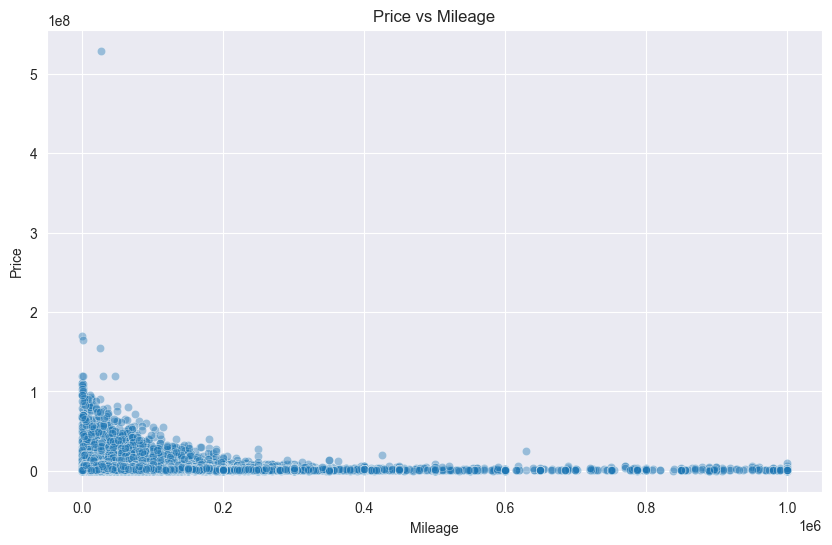

In [14]:
plt.figure()
sns.scatterplot(x=data2023['mileage'], y=data2023['price'], alpha=0.4)
plt.title("Price vs Mileage")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.show()

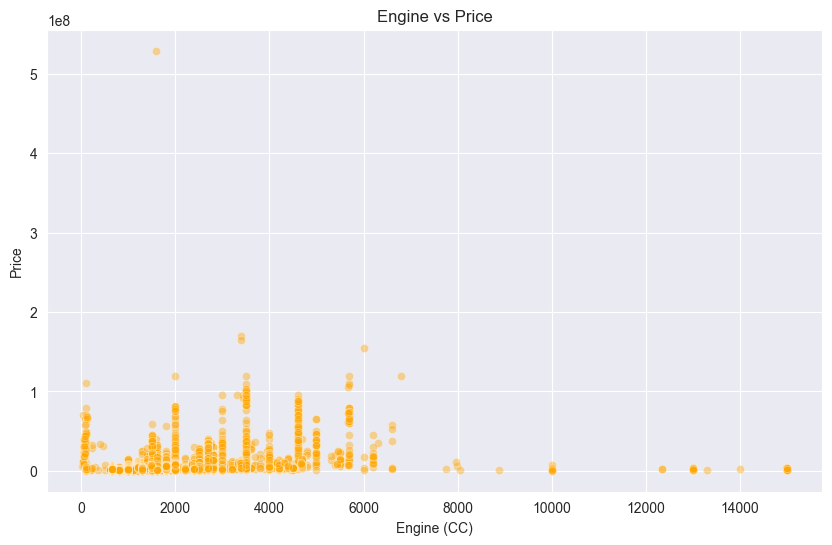

In [15]:

plt.figure()
sns.scatterplot(x=data2023['engine'], y=data2023['price'], alpha=0.4, color='orange')
plt.title("Engine vs Price")
plt.xlabel("Engine (CC)")
plt.ylabel("Price")
plt.show()

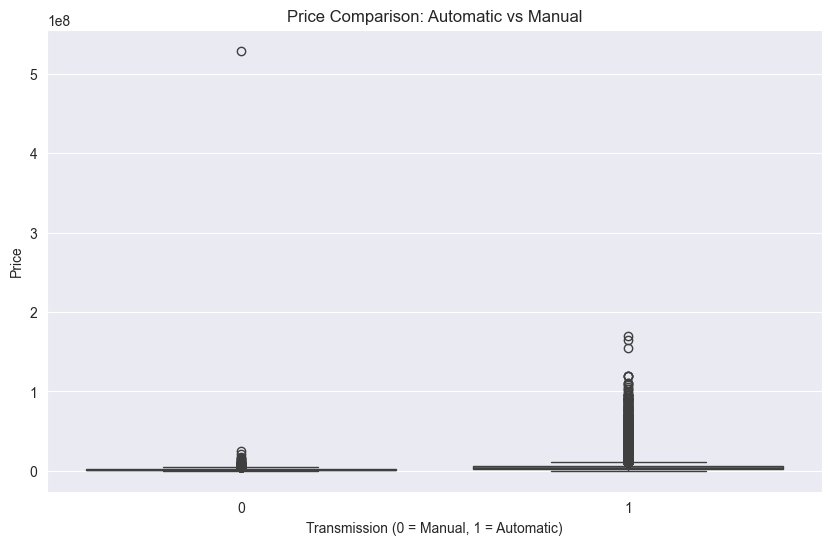

In [16]:

plt.figure()
sns.boxplot(x=data2023['transmission'], y=data2023['price'])
plt.title("Price Comparison: Automatic vs Manual")
plt.xlabel("Transmission (0 = Manual, 1 = Automatic)")
plt.ylabel("Price")
plt.show()


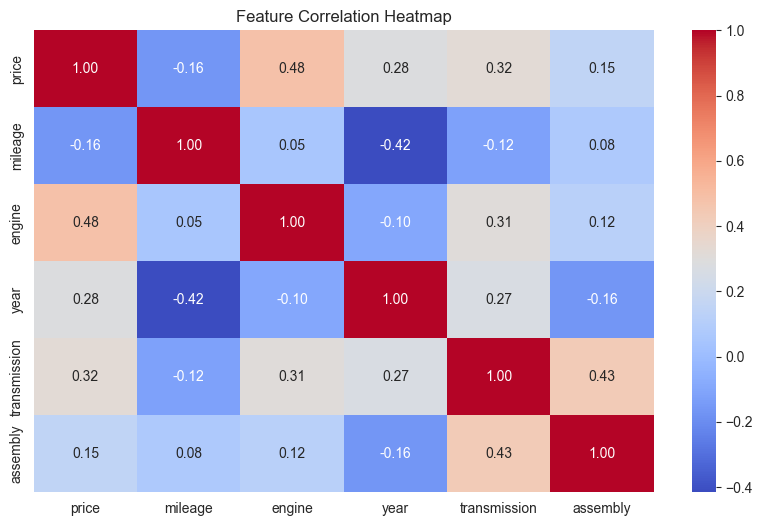

In [17]:
plt.figure()

corr = data2023[['price','mileage','engine','year','transmission','assembly']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Feature Correlation Heatmap")
plt.show()

Top 5 Models: ['Corolla', 'Civic', 'City', 'Mehran', 'Cultus']


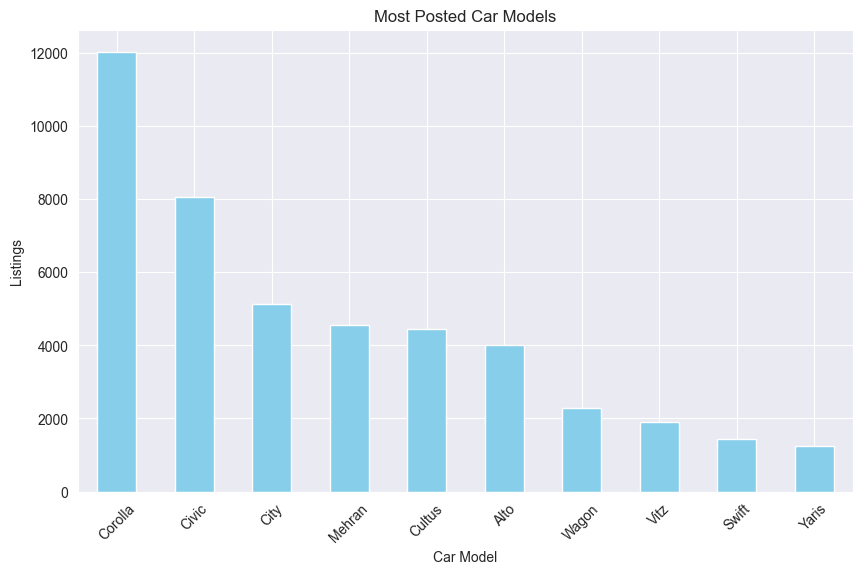

In [18]:
top_models = data2023['model'].value_counts().head(5).index.tolist()
print("Top 5 Models:", top_models)

plt.figure()
data2023['model'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title("Most Posted Car Models")
plt.xlabel("Car Model")
plt.ylabel("Listings")
plt.xticks(rotation=45)
plt.show()

In [20]:
def compute_cost(X, y, w, b, lambda_reg=0.01):

    m = len(y)

    predictions = X.dot(w) + b

    mse = (1/(2*m)) * np.sum((predictions - y)**2)

    reg = (lambda_reg/(2*m)) * np.sum(w**2)

    return mse + reg

In [21]:
def gradient_descent(X, y, w, b, learning_rate, epochs,
                     lambda_reg=0.01, tolerance=1e-6):

    m = len(y)
    prev_cost = float('inf')

    cost_history = []

    for i in range(epochs):

        predictions = X.dot(w) + b

        dw = (1/m) * X.T.dot(predictions - y) + (lambda_reg/m) * w
        db = (1/m) * np.sum(predictions - y)

        w -= learning_rate * dw
        b -= learning_rate * db

        cost = compute_cost(X, y, w, b, lambda_reg)

        cost_history.append(cost)

        if abs(prev_cost - cost) < tolerance:
            print(f"Early stopping at epoch {i}")
            break

        prev_cost = cost

        if i % 200 == 0:
            print(f"Epoch {i} | Cost: {cost}")

    # Plot training convergence
    plt.figure()
    plt.plot(cost_history)
    plt.title("Gradient Descent Convergence")
    plt.xlabel("Epoch")
    plt.ylabel("Cost")
    plt.show()

    return w, b

In [22]:

def r2_score(X, y, w, b):

    predictions = X.dot(w) + b

    ss_total = np.sum((y - y.mean())**2)

    ss_res = np.sum((y - predictions)**2)

    return 1 - (ss_res / ss_total)

# ============================================================
# 7. TRAIN MODEL FUNCTION
# ============================================================

def train_model(df):

    current_year = 2023
    df['age'] = current_year - df['year']

    feature_cols = ['assembly','age','engine','transmission','mileage']

    X = df[feature_cols].values
    y = df['price'].values.reshape(-1,1)

    # Normalize features
    X_mean = X.mean(axis=0)
    X_std = X.std(axis=0)
    X_std[X_std == 0] = 1

    X = (X - X_mean) / X_std

    # Normalize target
    y_mean = y.mean()
    y_std = y.std()

    if y_std == 0:
        y_std = 1

    y = (y - y_mean) / y_std

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    m, n = X_train.shape

    w = np.zeros((n,1))
    b = 0

    w, b = gradient_descent(
        X_train, y_train,
        w, b,
        learning_rate=0.01,
        epochs=2000,
        lambda_reg=0.01
    )

    val_r2 = r2_score(X_val, y_val, w, b)

    print("Validation R2:", val_r2)

    return {
        "w": w,
        "b": b,
        "X_mean": X_mean,
        "X_std": X_std,
        "y_mean": y_mean,
        "y_std": y_std
    }



Training model for: Corolla
Epoch 0 | Cost: 0.610265840746592
Epoch 200 | Cost: 0.5670072080084135
Epoch 400 | Cost: 0.5660165927579754
Early stopping at epoch 481


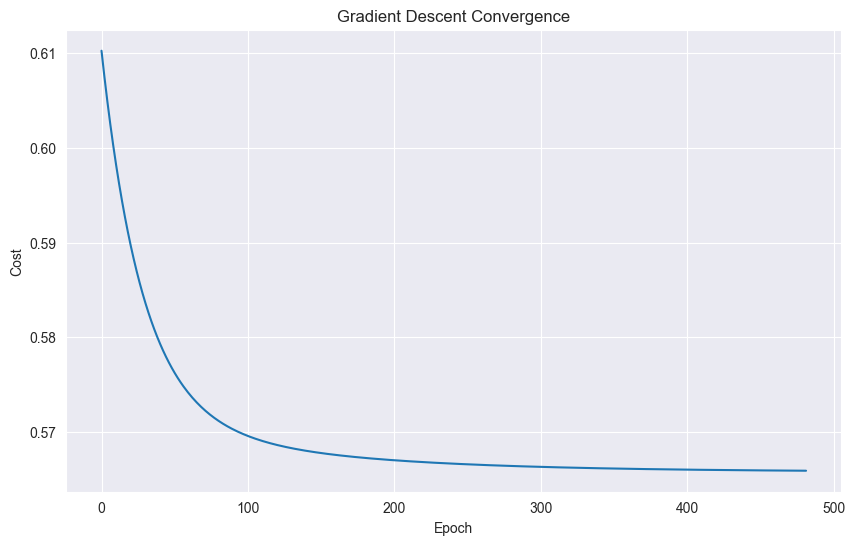

Validation R2: 0.8197407080108708

Training model for: Civic
Epoch 0 | Cost: 0.4926732096996605
Epoch 200 | Cost: 0.12188978590020227
Epoch 400 | Cost: 0.10887120553541134
Epoch 600 | Cost: 0.1057982451346608
Epoch 800 | Cost: 0.10505302752318295
Early stopping at epoch 875


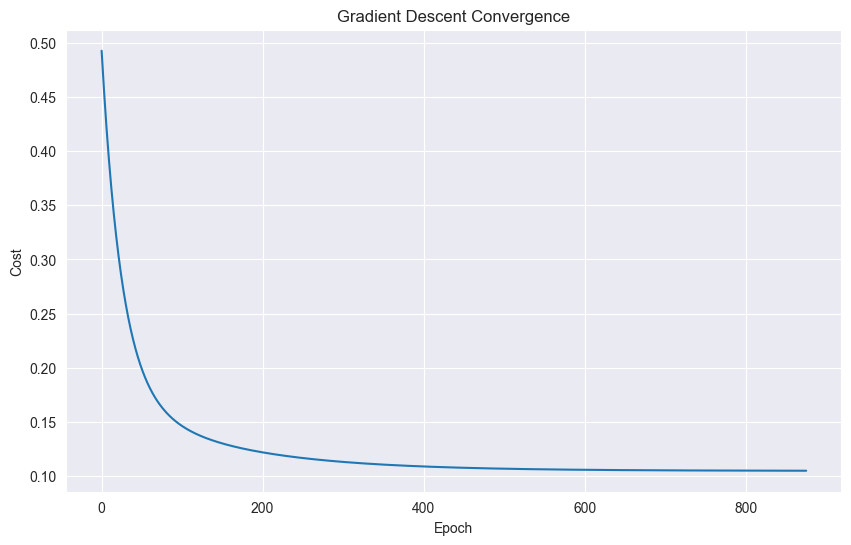

Validation R2: 0.8638846360003091

Training model for: City
Epoch 0 | Cost: 0.4821537607639232
Epoch 200 | Cost: 0.051070284042280034
Epoch 400 | Cost: 0.03970760503527925
Epoch 600 | Cost: 0.037836711306256085
Early stopping at epoch 738


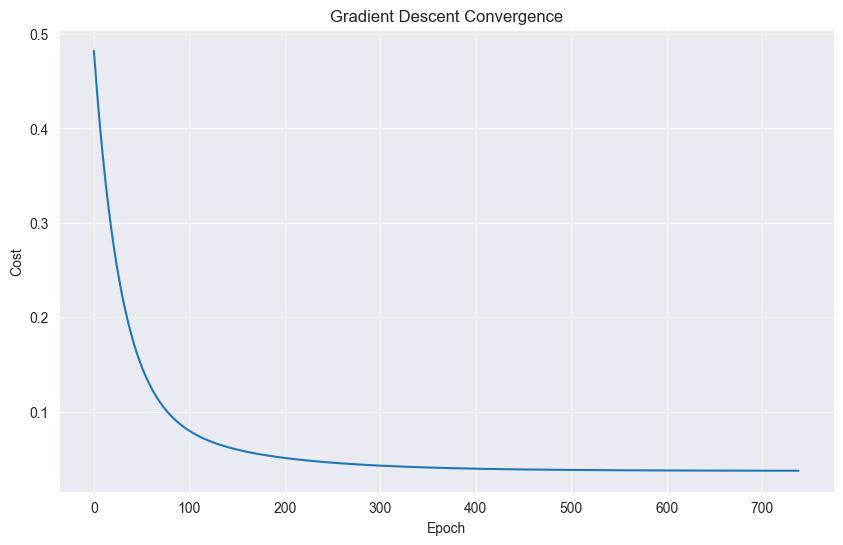

Validation R2: 0.9236202535687583

Training model for: Mehran
Epoch 0 | Cost: 0.49405619145855667
Epoch 200 | Cost: 0.12783857163822662
Epoch 400 | Cost: 0.11975631133431296
Early stopping at epoch 508


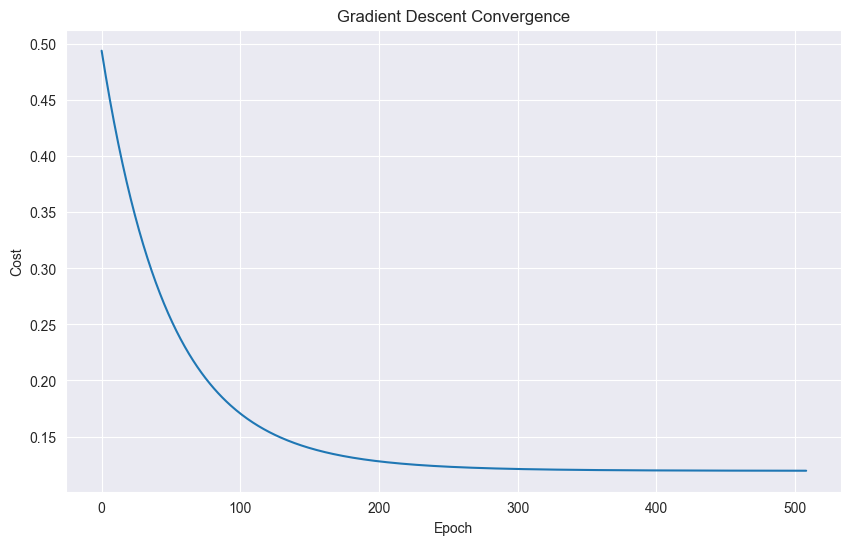

Validation R2: 0.7464294685155666

Training model for: Cultus
Epoch 0 | Cost: 0.4917386350456826
Epoch 200 | Cost: 0.08154141732336215
Epoch 400 | Cost: 0.07463937312372486
Early stopping at epoch 521


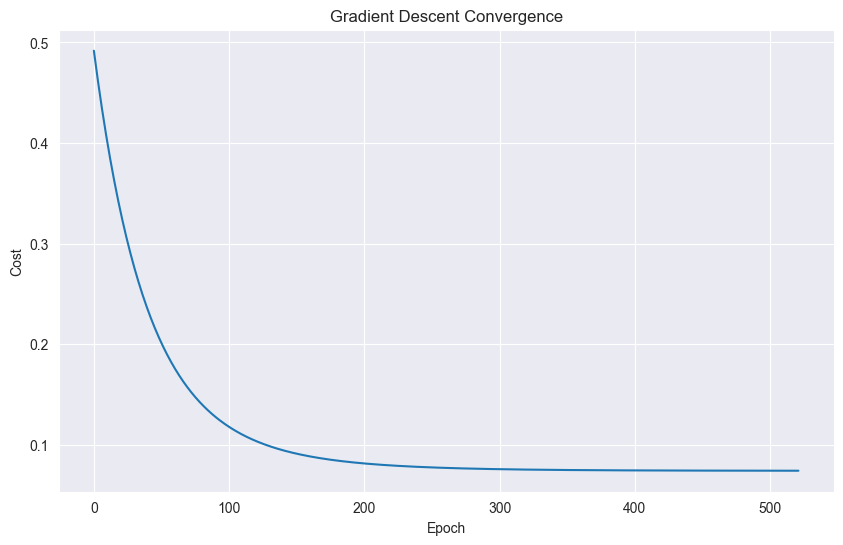

Validation R2: 0.8572962854394588

All models trained successfully!


In [23]:
models = {}

for car in top_models:

    print(f"\nTraining model for: {car}")

    df_car = data2023[data2023['model'] == car].copy()

    models[car] = train_model(df_car)

print("\nAll models trained successfully!")

In [25]:
def predict_price(car_model, assembly, year, engine,
                  transmission, mileage):

    if car_model not in models:
        return "Model not trained."

    model = models[car_model]

    age = 2023 - year

    x = np.array([assembly, age, engine,
                  transmission, mileage])

    x = (x - model["X_mean"]) / model["X_std"]

    pred_norm = x.dot(model["w"]) + model["b"]

    pred = pred_norm * model["y_std"] + model["y_mean"]

    return float(pred.item())

In [27]:
#==============fINAL PREDICTION==========================

test_price = predict_price(
    car_model=top_models[0],
    assembly=0,
    year=2015,
    engine=1300,
    transmission=1,
    mileage=60000
)

print("Predicted Price:", test_price)

Predicted Price: 4335100.643348336
